# Bifurcacion Transcritica

La forma normal de este tipo de Bifurcaciones es:

$$\dot x = rx - x^2$$

Donde sus punto de equilibrio son:
 $$x^{*} = 0\quad\text{y}\quad x^{*} = r$$

pero notemos que para $r = 0$ solo tenemos un punto de equilibrio

Asi esto nos dice que para $r<0$ hay 2 puntos de equilibrio

en $r=0$ solo tenemos uno, y para $r>0$ volvemos a tener 2 puntos de equilibrio

Ademas veamos como se comportan estos puntos de equilibrio

Como $$f(x) = rx - x^2$$ $$f´(x) = r - 2x$$ 

De donde:

- $f'(0) = r = \begin{cases}
\text{Inestable}\quad\text{Si}\quad r>0\\
\text{Estable}\quad\text{Si}\quad r<0
\end{cases}$ 

e inversamente

- $f'(r) = -r = \begin{cases}
\text{Estable}\quad\text{Si}\quad r>0\\
\text{Inestable}\quad\text{Si}\quad r<0
\end{cases}$

Ademas observemos que para $r=0$ no podemos decir nada de como se comporta $x^{*}=0$, pues $f'(0)=0$

Por lo tanto en este tipo de bifurcaión tenemos que para $r<0$ hay 2 puntos de equilibrio (uno estable y otro inestable)

En $r=0$ hay solo un punto de equilibrio y 

para $r>0$ volvemos a tener 2 puntos de equilibrio, pero en este caso se invierten las estabilidades

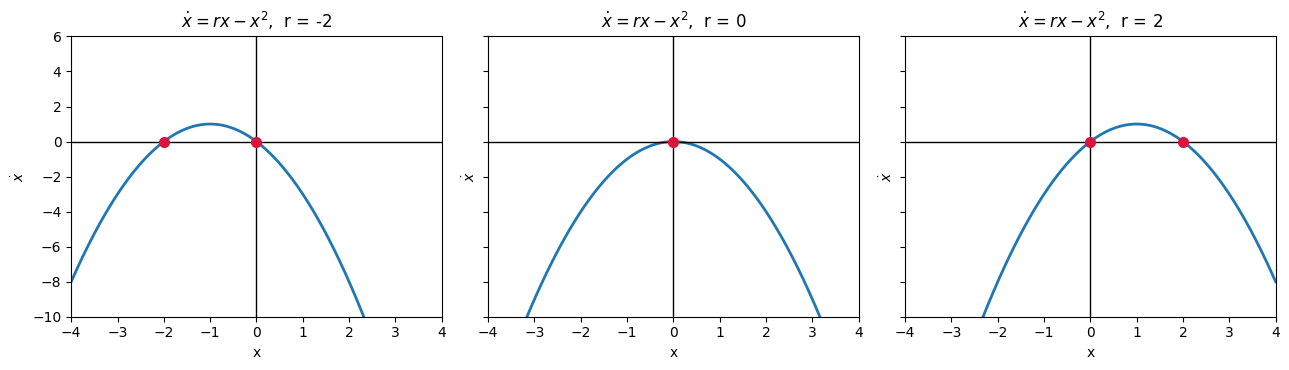

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def xdot(x, r):
    return r*x - x**2

rs = [-2, 0, 2]
x = np.linspace(-4, 4, 1200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)

for ax, r in zip(axes, rs):
    y = xdot(x, r)

    # curva x vs xdot
    ax.plot(x, y, linewidth=2)

    # ejes
    ax.axhline(0, color='k', lw=1)
    ax.axvline(0, color='k', lw=1)

    # equilibrios: x=0 y x=r (si r=0 coincide)
    eqs = sorted(set([0.0, float(r)]))
    for xeq in eqs:
        ax.plot(xeq, 0, 'o', color='crimson', ms=7, zorder=5)

    ax.set_title(f"$\\dot x = r x - x^2$,  r = {r}")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\dot x$")

ax.set_xlim(-4, 4)
ax.set_ylim(-10, 6)  # ajusta si quieres
plt.tight_layout()
plt.show()


**Ejemplo:**

$$
\dot{x} = x - a(1 - e^{-bx}).
$$

Tiene una bifurcación **transcrítica**.

Además, podemos aproximar
$$
x - a(1 - e^{-bx})
$$
con Taylor.

Consideremos que
$$
f(x) \approx f(0) + f'(0)x + \frac{f''(0)}{2}x^2 + O(x^3).
$$

Y
$$
f'(x) = 1 - ab e^{-bx},
\qquad
f'(0) = 1 - ab.
$$

$$
f''(x) = ab^2 e^{-bx},
\qquad
f''(0) = ab^2.
$$

Así,

$$
f(x) \approx (1 - ab)x + \frac{ab^2}{2}x^2.
$$

Por tanto:

$$
\dot{x} = (1 - ab)x + \frac{ab^2}{2}x^2.
$$

Multiplicando por $-\dfrac{ab^2}{2}$:

$$
-\frac{ab^2}{2}\dot{x}
= -\frac{ab^2}{2}(1 - ab)x - \left(\frac{ab^2}{2}x\right)^2.
= -\frac{ab}{2}(1 - ab)x - \left(\frac{ab^2}{2}x\right)^2.
$$

Y haciendo el cambio de variable

$$
y = -\frac{1}{2}ab^2 x,
\qquad
\dot{y} = -\frac{1}{2}ab^2 \dot{x},
$$

tenemos que

$$
\dot{y} = (1 - ab)y - y^2 = Ry - y^2,
$$

donde

$$
R = 1 - ab.
$$

Así, nuestro punto de bifurcación es en

$$
R = 0 \quad \text{es decir,} \quad ab = 1.
$$




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ========= Sistema =========
# x' = x(1 - x^2) - a(1 - e^{-b x})

def f_of_x(x, a, b):
    return x*(1 - x**2) - a*(1 - np.exp(-b*x))

def dfdx(x, a, b):
    # derivada de f respecto a x
    return 1 - 3*x**2 - a*b*np.exp(-b*x)

# -------- util: raíces por bisección sobre cambios de signo --------
def find_roots_bisection(func, x_min, x_max, a, b, n_samples=2000, max_iter=50, tol=1e-10):
    xs = np.linspace(x_min, x_max, n_samples)
    fs = func(xs, a, b)
    roots = []

    for i in range(len(xs)-1):
        x0, x1 = xs[i], xs[i+1]
        f0, f1 = fs[i], fs[i+1]

        # raíz exacta en malla
        if np.isfinite(f0) and abs(f0) < 1e-14:
            roots.append(x0)
            continue

        # cambio de signo
        if (f0 == 0) or (f1 == 0) or (f0 * f1 < 0):
            left, right = x0, x1
            fl, fr = f0, f1

            if abs(fl) < 1e-14:
                roots.append(left); continue
            if abs(fr) < 1e-14:
                roots.append(right); continue
            if fl*fr > 0:
                continue

            for _ in range(max_iter):
                mid = 0.5*(left + right)
                fm = func(mid, a, b)
                if abs(fm) < tol:
                    left = right = mid
                    break
                if fl*fm <= 0:
                    right = mid; fr = fm
                else:
                    left = mid; fl = fm
            roots.append(0.5*(left + right))

    # deduplicar
    roots = np.array(sorted(roots))
    if roots.size == 0:
        return []
    unique = [roots[0]]
    for x in roots[1:]:
        if abs(x - unique[-1]) > 1e-6:
            unique.append(x)
    return unique

# -------- visualización principal --------
def plot_all(a=1.0, b=1.0):
    t_end = 10.0  # se puede hacer slider si quieres
    # rango para x adaptable
    xrang = max(3.0, 1.5*abs(a) + 2.0)
    x = np.linspace(-xrang, xrang, 2000)
    fx = f_of_x(x, a, b)

    # (1) f(x) vs x (fase 1D) con equilibrios y estabilidad
    plt.figure(figsize=(6.4, 4.6))
    plt.axhline(0, linewidth=1.0, color='k')
    plt.axvline(0, linewidth=1.0, color='k')
    plt.plot(x, fx, label=rf"$\dot x = x(1-x^2) - a(1-e^{{-b x}})$")

    roots = find_roots_bisection(f_of_x, -xrang, xrang, a, b, n_samples=3000)
    for xe in roots:
        lam = dfdx(xe, a, b)
        facecolor = "white" if lam < 0 else "black"  # blanco = estable, negro = inestable
        plt.scatter([xe], [0], s=65, edgecolor="k", facecolor=facecolor, zorder=5)

    plt.xlabel("x"); plt.ylabel(r"$\dot{x}$")
    plt.title(fr"Fase 1D   (a={a:.3f}, b={b:.3f})")
    plt.grid(True, alpha=0.3); plt.legend(loc="best"); plt.tight_layout(); plt.show()

    # (2) Campo direccional en (t,x)
    t_vals = np.linspace(0.0, t_end, 25)
    x_vals = np.linspace(-xrang, xrang, 25)
    T, X = np.meshgrid(t_vals, x_vals)
    S = f_of_x(X, a, b)  # autónomo
    U = np.ones_like(S); V = S
    N = np.sqrt(U**2 + V**2) + 1e-12
    U_n, V_n = U/N, V/N

    plt.figure(figsize=(7.0, 4.8))
    plt.quiver(T, X, U_n, V_n, angles="xy", scale_units="xy", pivot="mid")
    for xe in roots:
        plt.hlines(xe, 0, t_end, linestyles="--")
    plt.xlabel("t"); plt.ylabel("x")
    plt.title(fr"Campo direccional   (a={a:.3f}, b={b:.3f})")
    plt.xlim(0, t_end); plt.ylim(-xrang, xrang)
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # (3) Escaneo tipo bifurcación: x*(a) con b fijo
    a_min, a_max = -3.0, 3.0
    a_grid = np.linspace(a_min, a_max, 241)
    scan_xmin, scan_xmax = -max(xrang, 4.0), max(xrang, 4.0)

    xs_stable, as_stable = [], []
    xs_unstable, as_unstable = [], []

    for aa in a_grid:
        roots_a = find_roots_bisection(f_of_x, scan_xmin, scan_xmax, aa, b, n_samples=1200)
        for xe in roots_a:
            lam = dfdx(xe, aa, b)
            if lam < 0:
                xs_stable.append(xe); as_stable.append(aa)
            else:
                xs_unstable.append(xe); as_unstable.append(aa)

    plt.figure(figsize=(6.4, 4.9))
    if as_stable:
        plt.scatter(as_stable, xs_stable, s=10, label="estable", edgecolors='none')
    if as_unstable:
        plt.scatter(as_unstable, xs_unstable, s=10, facecolors='none', edgecolors='k', label="inestable")

    plt.axvline(a, linestyle=":", linewidth=1.2)
    plt.axhline(0, linewidth=1.0, color='k')
    plt.xlabel("parámetro a (b fijo)"); plt.ylabel("equilibrio x*")
    plt.title(fr"Equilibrios vs a   (b = {b:.3f})")
    plt.xlim(a_min, a_max); plt.ylim(scan_xmin, scan_xmax)
    plt.legend(frameon=False); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# -------- sliders (solo a y b) --------
_ = interact(
    plot_all,
    a=FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.01, description="a"),
    b=FloatSlider(value=1.0, min=0.0,  max=3.0, step=0.01, description="b"),
)


interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0, step=0.01), FloatSlider(value…

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def f(x, a, b):
    return x - a*(1 - np.exp(-b*x))

@interact(
    a=FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.01, description='a'),
    b=FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.01, description='b'),
    x_min=FloatSlider(value=-5.0, min=-20.0, max=0.0, step=0.5, description='x_min'),
    x_max=FloatSlider(value=5.0,  min=0.0,  max=20.0, step=0.5, description='x_max'),
)
def phase_plot(a, b, x_min, x_max):
    if x_max <= x_min:
        print("Ajusta: x_max debe ser mayor que x_min.")
        return
    
    x = np.linspace(x_min, x_max, 2000)
    xdot = f(x, a, b)

    plt.figure(figsize=(7, 4.5))
    plt.axhline(0, linewidth=1)          # línea xdot=0
    plt.plot(x, xdot)                    # retrato de fase 1D: xdot vs x
    plt.xlabel("x")
    plt.ylabel("ẋ")
    plt.title(rf"Retrato de fase: $\dot x = x - a(1-e^{{-bx}})$   (a={a:.2f}, b={b:.2f})")
    plt.grid(True, alpha=0.3)
    plt.show()

    # (Opcional) "línea de fase": flechas indicando el signo de xdot sobre el eje x
    xs = np.linspace(x_min, x_max, 25)
    sgn = np.sign(f(xs, a, b))
    sgn[sgn == 0] = 1
    plt.figure(figsize=(7, 1.4))
    plt.scatter(xs, np.zeros_like(xs), c=(sgn > 0), s=30)
    for xi, si in zip(xs, sgn):
        plt.arrow(xi, 0, 0.25*si*(x_max-x_min)/25, 0,
                  head_width=0.06, head_length=0.12, length_includes_head=True)
    plt.yticks([])
    plt.xlabel("x")
    plt.title("Línea de fase (dirección del flujo sobre x)")
    plt.grid(True, axis="x", alpha=0.2)
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0, step=0.01), FloatSlider(value…

# Ejemplo

Consideremos ahora el sistema 
$$\dot x = r\ln x + x-1$$

notemos primero que $x^{*} = 1$ es punto de equilibrio y como $$f(x)=r \ln x + x - 1$$

expandamos con taylor al rededor de x=1, por lo que calculemos hasta la segunda derivada, asi:

- $f'(x)=\frac{r}{x} + 1$, entonces $f'(1)=r+1$

- $f''(x) = -\frac{r}{x^2}$, entonces $f''(1)= -1$

con esto, tenemos que $$f(x) \approx f(1) + f'(1)(x-1) + \frac{1}{2}f''(1)(x-1)^2 + o(x^3) \approx (r+1)(x-1)-\frac{1}{2}r(x-1)^2$$

por tanto $$\dot x = (r+1)(x-1)-\frac{1}{2}r(x-1)^2$$ y multiplicando ahora todo por $\displaystyle\frac{r}{2} $ tenemos que:

$$\frac{r}{2}\dot x = \frac{r}{2}(r+1)(x-1)-(\frac{r}{2})^2(x-1)^2$$

si tomamos ahora $$y=\frac{r}{2}(x-1)\quad\text{entonces}\quad\dot y = \frac{r}{2}\dot x = \frac{r}{2}(r+1)(x-1)-(\frac{r}{2})^2(x-1)^2 = (r+1)y - y^2$$

Es decir $$\dot y = (r+1)y - y^2$$

por tanto, esto nos dice que en $r=-1$ tenemos una bifurcación transcritica

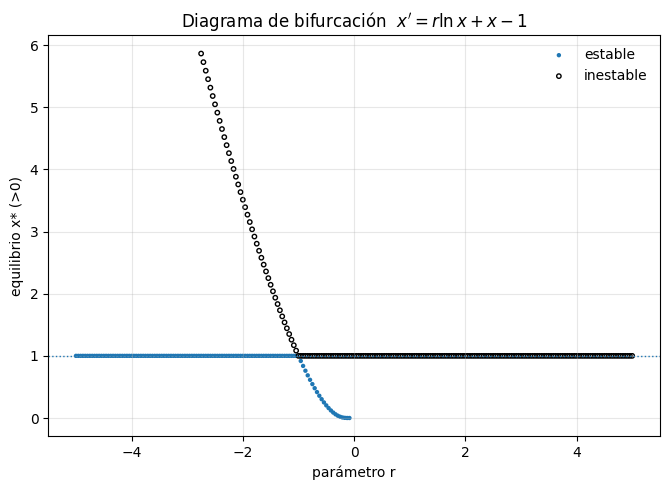

interactive(children=(FloatSlider(value=1.0, description='r', max=5.0, min=-5.0, step=0.01), Output()), _dom_c…

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# (opcional) sliders
try:
    from ipywidgets import interact, FloatSlider
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

EPS = 1e-8  # para evitar log(0)

# -------- Sistema --------
# f(x) = r ln x + x - 1
def f_of_x(x, r):
    return r*np.log(x) + x - 1

def dfdx(x, r):
    # f'(x) = r/x + 1
    return r/x + 1

# -------- Búsqueda de raíces: bisección en cambios de signo --------
def find_roots_bisection(func, x_min, x_max, r, n_samples=2000, max_iter=60, tol=1e-12):
    xs = np.linspace(max(x_min, EPS), x_max, n_samples)
    fs = func(xs, r)
    roots = []

    for i in range(len(xs)-1):
        x0, x1 = xs[i], xs[i+1]
        f0, f1 = fs[i], fs[i+1]

        # raíz exacta en malla
        if np.isfinite(f0) and abs(f0) < 1e-14:
            roots.append(x0); continue

        # cambio de signo o extremo ~0
        if (f0 == 0) or (f1 == 0) or (f0*f1 < 0):
            left, right = x0, x1
            fl, fr = f0, f1
            if abs(fl) < 1e-14: roots.append(left);  continue
            if abs(fr) < 1e-14: roots.append(right); continue
            if fl*fr > 0:       continue

            # bisección
            for _ in range(max_iter):
                mid = 0.5*(left + right)
                fm  = func(mid, r)
                if abs(fm) < tol:
                    left = right = mid
                    break
                if fl*fm <= 0:
                    right, fr = mid, fm
                else:
                    left,  fl = mid, fm
            roots.append(0.5*(left + right))

    # deduplicar raíces cercanas
    roots = np.array(sorted(roots))
    if roots.size == 0:
        return []
    uniq = [roots[0]]
    for x in roots[1:]:
        if abs(x - uniq[-1]) > 1e-6:
            uniq.append(x)
    return uniq

# -------- (1) Diagrama de bifurcación: x*(r) --------
def plot_bifurcation(r_min=-5.0, r_max=5.0):
    r_grid = np.linspace(r_min, r_max, 241)
    xs_stable, rs_stable = [], []
    xs_unst,   rs_unst   = [], []

    # rango para buscar raíces en x
    scan_xmin, scan_xmax = EPS, 6.0

    for rr in r_grid:
        roots = find_roots_bisection(f_of_x, scan_xmin, scan_xmax, rr, n_samples=2200)
        # asegurar inclusión de x=1 (siempre raíz)
        if 1.0 <= scan_xmax and all(abs(rt-1.0) > 1e-6 for rt in roots):
            roots.append(1.0)

        for xe in roots:
            lam = dfdx(xe, rr)
            if lam < 0:
                xs_stable.append(xe); rs_stable.append(rr)
            else:
                xs_unst.append(xe);   rs_unst.append(rr)

    plt.figure(figsize=(6.8, 5.0))
    if rs_stable:
        plt.scatter(rs_stable, xs_stable, s=10, label="estable", edgecolors='none')         # relleno
    if rs_unst:
        plt.scatter(rs_unst,   xs_unst,   s=10, facecolors='none', edgecolors='k',
                    label="inestable")                                                       # hueco
    plt.axhline(1.0, linestyle=':', linewidth=1.0)  # referencia x=1
    plt.xlabel("parámetro r"); plt.ylabel("equilibrio x* (>0)")
    plt.title(r"Diagrama de bifurcación  $x' = r\ln x + x - 1$")
    plt.grid(True, alpha=0.3); plt.legend(frameon=False)
    plt.tight_layout(); plt.show()

# -------- (2) Curvas y = r ln x y y = 1 - x (intersecciones) --------
def plot_curves(r=1.0):
    x = np.linspace(1e-4, 6.0, 1200)
    y1 = r*np.log(x)
    y2 = 1 - x

    plt.figure(figsize=(6.8, 5.0))
    plt.plot(x, y1, label=r"$y = r\ln x$")
    plt.plot(x, y2, label=r"$y = 1 - x$")

    # marcar intersecciones (equilibrios)
    roots = find_roots_bisection(f_of_x, 1e-4, 6.0, r, n_samples=2000)
    if 1.0 <= 6.0 and all(abs(rt-1.0) > 1e-6 for rt in roots):
        roots.append(1.0)
    for xe in roots:
        plt.scatter([xe], [1 - xe], s=40, edgecolor='k', facecolor='white', zorder=5)

    plt.axhline(0, linewidth=1.0)
    plt.xlabel("x (>0)"); plt.ylabel("y")
    plt.title(r"Intersección de $y=r\ln x$ y $y=1-x$" + f"   (r={r:.2f})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- Ejecuta las figuras ----
plot_bifurcation()

if HAVE_WIDGETS:
    # Gráfica interactiva para las curvas
    _ = interact(
        plot_curves,
        r=FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.01, description="r"),
    )
else:
    # Render estático si no hay ipywidgets
    plot_curves(r=1.0)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ----- sistema -----
def f_of_x(x, a, b):
    return x*(1 - x**2) - a*(1 - np.exp(-b*x))

def dfdx(x, a, b):
    return 1 - 3*x**2 - a*b*np.exp(-b*x)

# ----- raíces por bisección sobre cambios de signo -----
def find_roots_bisection(func, x_min, x_max, a, b, n_samples=1600, max_iter=50, tol=1e-10):
    xs = np.linspace(x_min, x_max, n_samples)
    fs = func(xs, a, b)
    roots = []
    for i in range(len(xs)-1):
        x0, x1 = xs[i], xs[i+1]
        f0, f1 = fs[i], fs[i+1]

        # raíz exacta en malla
        if np.isfinite(f0) and abs(f0) < 1e-14:
            roots.append(x0); continue

        # cambio de signo
        if (f0 == 0) or (f1 == 0) or (f0*f1 < 0):
            left, right = x0, x1
            fl, fr = f0, f1
            if abs(fl) < 1e-14: roots.append(left);  continue
            if abs(fr) < 1e-14: roots.append(right); continue
            if fl*fr > 0:       continue

            for _ in range(max_iter):
                mid = 0.5*(left + right)
                fm = func(mid, a, b)
                if abs(fm) < tol:
                    left = right = mid
                    break
                if fl*fm <= 0:
                    right, fr = mid, fm
                else:
                    left,  fl = mid, fm
            roots.append(0.5*(left + right))

    # deduplicar
    roots = np.array(sorted(roots))
    if roots.size == 0:
        return []
    uniq = [roots[0]]
    for x in roots[1:]:
        if abs(x - uniq[-1]) > 1e-6:
            uniq.append(x)
    return uniq

# ----- diagrama de bifurcación: x*(a) con b fijo -----
def bifurcation_only(b=1.0):
    a_min, a_max = -3.0, 3.0
    a_grid = np.linspace(a_min, a_max, 241)

    # rango x para buscar raíces (amplio y simétrico)
    xrang = 5.0
    scan_xmin, scan_xmax = -xrang, xrang

    xs_stable, as_stable = [], []
    xs_unstable, as_unstable = [], []

    for aa in a_grid:
        roots = find_roots_bisection(f_of_x, scan_xmin, scan_xmax, aa, b, n_samples=2000)
        for xe in roots:
            lam = dfdx(xe, aa, b)
            if lam < 0:
                xs_stable.append(xe); as_stable.append(aa)
            else:
                xs_unstable.append(xe); as_unstable.append(aa)

    plt.figure(figsize=(6.4, 4.9))
    if as_stable:
        plt.scatter(as_stable, xs_stable, s=10, label="estable", edgecolors='none')          # relleno
    if as_unstable:
        plt.scatter(as_unstable, xs_unstable, s=10, facecolors='none', label="inestable")                                                         # hueco
    plt.axhline(0, color='k', linewidth=1.0)
    plt.xlabel("parámetro a")
    plt.ylabel("equilibrio x*")
    plt.title(r"Diagrama de bifurcación  $\dot x = x(1-x^2) - a(1-e^{-b x})$" + f"   (b={b:.2f})")
    plt.xlim(a_min, a_max); plt.ylim(scan_xmin, scan_xmax)
    plt.legend(frameon=False); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

# ---- slider solo para b ----
_ = interact(
    bifurcation_only,
    b=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.01, description="b"),
)


interactive(children=(FloatSlider(value=1.0, description='b', max=3.0, step=0.01), Output()), _dom_classes=('w…

# Ejemplo

Determinemos los puntos de bifurcación $(x^*,\mu_{crit})$ dibujemos el espacio fase para  
$\mu > \mu_{crit}$ y $\mu < \mu_{crit}$ del sistema

$$
\dot{x} = \mu x - c x^2, \qquad c \neq 0.
$$

Notemos que el sistema tiene la **forma normal de una bifurcación transcrítica**, pues:

$$
\dot{x} = \mu x - c x^2.
$$

$$
c\dot{x} = c\mu x - c^2 x^2.
$$
Haciendo el cambio de variable

$$
y = c x,
$$

se obtiene

$$
\dot{y} = c \dot{x}.
$$

Por tanto,

$$
\dot{y} = \mu y - y^2.
$$

De aquí se concluye que el valor crítico del parámetro es

$$
\mu_{crit} = 0
$$

y los puntos de equilibrio son:

$$
y_1^* = 0\quad \text{y}\quad y_2^*=\mu
$$

Y sabemos que para $\mu > 0$

$$
y_1^* = 0 \quad \text{es inestable}
$$

$$
y_2^* = \mu\quad\text{es estable}
$$

y para $\mu < 0$

$$
y_1^* = 0 \quad \text{es estable}
$$

$$
y_2^* = \mu\quad\text{es inestable}
$$

# Bifurcación en $\dot x=\mu-A\cos(\pi x)$

Consideremos el sistema 1D
$$
\dot x=f(x;\mu)=\mu-A\cos(\pi x),\qquad A>0.
$$

---

## 1) Puntos de equilibrio

Los equilibrios satisfacen $\dot x=0$:
$$
0=\mu-A\cos(\pi x)\quad \Longleftrightarrow\quad \mu=A\cos(\pi x).
$$

Como $|\cos(\pi x)|\le 1$, se requiere
$$
\left|\frac{\mu}{A}\right|\le 1
\quad \Longleftrightarrow\quad
|\mu|\le A.
$$

- **Si $|\mu|>A$**: **no hay equilibrios**.
  - Si $\mu>A$: $\dot x\ge \mu-A>0$ (flujo hacia $+\infty$).
  - Si $\mu<-A$: $\dot x\le \mu+A<0$ (flujo hacia $-\infty$).

- **Si $|\mu|\le A$**: sí hay equilibrios.

---

## 2) Expresión explícita de los equilibrios ($|\mu|\le A$)

De $\cos(\pi x)=\mu/A$,
$$
\pi x=\pm\arccos\!\left(\frac{\mu}{A}\right)+2\pi k,\qquad k\in\mathbb Z,
$$
por lo que
$$
\boxed{
x^*_{k,\pm}(\mu)=2k\ \pm\ \frac{1}{\pi}\arccos\!\left(\frac{\mu}{A}\right)
}
\qquad (k\in\mathbb Z).
$$

---

## 3) Estabilidad

$$
f'(x)=\frac{d}{dx}\big(\mu-A\cos(\pi x)\big)=A\pi\sin(\pi x).
$$

En 1D:
- $x^*$ es **estable** si $f'(x^*)<0$,
- $x^*$ es **inestable** si $f'(x^*)>0$.

Como $A\pi>0$, el signo depende de $\sin(\pi x^*)$:

- En cada intervalo $(2k,\,2k+1)$: $\sin(\pi x)>0$ $\Rightarrow$ **inestable**.
- En cada intervalo $(2k-1,\,2k)$: $\sin(\pi x)<0$ $\Rightarrow$ **estable**.

En particular, para las dos ramas:
$$
x^*_{k,+}(\mu)=2k+\frac{1}{\pi}\arccos(\mu/A)\in[2k,\,2k+1]
\Rightarrow \textbf{inestable}
$$

$$
x^*_{k,-}(\mu)=2k-\frac{1}{\pi}\arccos(\mu/A)\in[2k-1,\,2k]
\Rightarrow \textbf{estable}
$$

(salvo en los puntos extremos donde se “pegan” las ramas).

---

## 4) Puntos de bifurcación y tipo

Los puntos de bifurcación (colisión/desaparición de equilibrios) ocurren cuando
$$
f(x^*;\mu)=0
\quad \text{y}\quad
f'(x^*)=0.
$$

De $f'(x^*)=A\pi\sin(\pi x^*)=0$ se obtiene $x^*\in\mathbb Z$.
Entonces:

- Si $x^*=2k$ (par), $\cos(\pi x^*)=1$ $\Rightarrow$ $\boxed{\mu=A}$.
- Si $x^*=2k+1$ (impar), $\cos(\pi x^*)=-1$ $\Rightarrow$ $\boxed{\mu=-A}$.

Por tanto, en $\mu=\pm A$ aparece/desaparece un par (estable–inestable) por período:
$$
\boxed{\text{Bifurcaciones saddle-node (pliegue) en }\mu=\pm A.}
$$

---

## 5) Diagrama de bifurcación (descripción)

- Para $|\mu|<A$: existen **dos** equilibrios por cada $k$:
  - una rama **estable** $x^*_{k,-}(\mu)$ (dibujar **línea continua**),
  - una rama **inestable** $x^*_{k,+}(\mu)$ (dibujar **línea punteada**).
- En $\mu=A$: ambas ramas se juntan en $x=2k$.
- En $\mu=-A$: ambas ramas se juntan en $x=2k+1$.
- Para $|\mu|>A$: **no hay equilibrios**.

Equivalentemente, el conjunto de equilibrios en el plano $(x,\mu)$ es la curva:
$$
\mu=A\cos(\pi x),
$$
y el diagrama $x^*(\mu)$ se obtiene “leyendo” sus ramas para $\mu\in[-A,A]$, repitiéndose cada 2 unidades en $x$.
